# 001 – Data Understanding
**SunnyX Forecasting System (SFS)**

---

## Goal
Carry out a structured data understanding exercise across all SFS tables to:
- Understand the shape, schema, and grain of each dataset
- Identify data quality issues (nulls, duplicates, type mismatches)
- Explore distributions and coverage of key variables
- Document observations that will inform modelling decisions

---

## Dataset Layers
| Layer | Tables |
|---|---|
| Foundation (Dimensions) | `dim_stores`, `dim_products`, `dim_calendar`, `dim_policy_regimes` |
| Transactions | `fact_sales`, `fact_inventory`, `fact_promotions` |
| Behaviour & Operations | `fact_customer_activity`, `fact_store_operations` |
| Policy & Constraints | `fact_restriction_events` |
| External | `fact_weather` |

---
## 0. Imports

In [1]:
# Install required packages if not already present
import subprocess, sys

packages = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'sqlalchemy',
    'psycopg2-binary',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages ready.')


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


All packages ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

---
## 1. Database Connection

In [5]:
# ------------------------------------
# Connection – update credentials below
# ------------------------------------
host     = "aws-1-eu-central-1.pooler.supabase.com"
port     = 5432
database = "postgres"
user     = "uddy.ogkdfmkybqtrsglcizzt"
password = quote_plus("Uddodirim123")

engine = create_engine(
    f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}",
    pool_pre_ping=True,
    connect_args={
        "options": "-c statement_timeout=300000"   # 5-minute timeout (ms)
    }
)

# Quick connection test
test = pd.read_sql("SELECT current_user, current_database()", engine)
print("Connected as:", test.iloc[0, 0], "| DB:", test.iloc[0, 1])

Connected as: uddy | DB: postgres


---
## 2. Load All Tables

In [6]:
# ---- Dimension Tables (load fully – small) ----
df_stores         = pd.read_sql("SELECT * FROM core.dim_stores ORDER BY store_id", engine)
df_products       = pd.read_sql("SELECT * FROM core.dim_products ORDER BY product_id", engine)
df_calendar       = pd.read_sql("SELECT * FROM core.dim_calendar ORDER BY date", engine)
df_policy_regimes = pd.read_sql("SELECT * FROM core.dim_policy_regimes ORDER BY start_date", engine)

# ---- Fact Tables (sampled for exploration – 100k rows each) ----
# Full tables are large (1.6M+ rows). We use a random sample for data understanding.
# To load in full, remove the TABLESAMPLE clause.
SAMPLE_PCT = 6   # ~6% ≈ 100k rows from 1.6M fact_sales

df_sales = pd.read_sql(f"""
    SELECT * FROM core.fact_sales
    TABLESAMPLE BERNOULLI({SAMPLE_PCT})
    ORDER BY date
""", engine)

df_inventory = pd.read_sql(f"""
    SELECT * FROM core.fact_inventory
    TABLESAMPLE BERNOULLI({SAMPLE_PCT})
    ORDER BY date
""", engine)

df_promotions = pd.read_sql("""
    SELECT * FROM core.fact_promotions
    ORDER BY date
    LIMIT 100000
""", engine)

df_customer_act = pd.read_sql("""
    SELECT * FROM core.fact_customer_activity
    ORDER BY date
    LIMIT 100000
""", engine)

df_store_ops = pd.read_sql("""
    SELECT * FROM core.fact_store_operations
    ORDER BY date
    LIMIT 100000
""", engine)

df_restrictions = pd.read_sql("SELECT * FROM core.fact_restriction_events ORDER BY date", engine)
df_weather      = pd.read_sql("SELECT * FROM core.fact_weather ORDER BY date", engine)

print("Tables loaded:")
for name, df in [
    ('dim_stores', df_stores), ('dim_products', df_products),
    ('dim_calendar', df_calendar), ('dim_policy_regimes', df_policy_regimes),
    ('fact_sales (sample)', df_sales), ('fact_inventory (sample)', df_inventory),
    ('fact_promotions', df_promotions), ('fact_customer_activity', df_customer_act),
    ('fact_store_operations', df_store_ops), ('fact_restriction_events', df_restrictions),
    ('fact_weather', df_weather),
]:
    print(f"  {name:<30} {df.shape[0]:>8,} rows x {df.shape[1]} cols")

Tables loaded:
  dim_stores                            7 rows x 7 cols
  dim_products                        120 rows x 8 cols
  dim_calendar                      1,935 rows x 12 cols
  dim_policy_regimes                   16 rows x 10 cols
  fact_sales (sample)              97,477 rows x 20 cols
  fact_inventory (sample)          97,536 rows x 7 cols
  fact_promotions                     757 rows x 6 cols
  fact_customer_activity           13,545 rows x 9 cols
  fact_store_operations            13,545 rows x 8 cols
  fact_restriction_events          36,938 rows x 8 cols
  fact_weather                     13,545 rows x 5 cols


In [7]:
import pandas as pd

# -------------------------
# DIM TABLES
# -------------------------

df_calendar = pd.read_sql("""
SELECT * FROM core.dim_calendar
ORDER BY date ASC
""", engine)

df_policy_regimes = pd.read_sql("""
SELECT * FROM core.dim_policy_regimes
ORDER BY start_date ASC
""", engine)

df_products = pd.read_sql("""
SELECT * FROM core.dim_products
ORDER BY product_id ASC
""", engine)

df_stores = pd.read_sql("""
SELECT * FROM core.dim_stores
ORDER BY store_id ASC
""", engine)


# -------------------------
# FACT TABLES
# -------------------------

df_sales = pd.read_sql("""
SELECT * FROM core.fact_sales
ORDER BY date ASC
""", engine)

df_inventory = pd.read_sql("""
SELECT * FROM core.fact_inventory
ORDER BY date ASC
""", engine)

df_customer_activity = pd.read_sql("""
SELECT * FROM core.fact_customer_activity
ORDER BY date ASC
""", engine)

df_store_operations = pd.read_sql("""
SELECT * FROM core.fact_store_operations
ORDER BY date ASC
""", engine)

df_promotions = pd.read_sql("""
SELECT * FROM core.fact_promotions
ORDER BY date ASC
""", engine)

df_restrictions = pd.read_sql("""
SELECT * FROM core.fact_restriction_events
ORDER BY date ASC
""", engine)

df_weather = pd.read_sql("""
SELECT * FROM core.fact_weather
ORDER BY date ASC
""", engine)

---
## 3. Dataset Inventory – Shape & Schema Overview

In [8]:
tables = {
    'dim_stores':           df_stores,
    'dim_products':         df_products,
    'dim_calendar':         df_calendar,
    'dim_policy_regimes':   df_policy_regimes,
    'fact_sales':           df_sales,
    'fact_inventory':       df_inventory,
    'fact_promotions':      df_promotions,
    'fact_customer_activity': df_customer_act,
    'fact_store_operations':  df_store_ops,
    'fact_restriction_events': df_restrictions,
    'fact_weather':         df_weather,
}

summary = pd.DataFrame([
    {
        'Table':   name,
        'Rows':    df.shape[0],
        'Columns': df.shape[1],
        'Null Cells': df.isnull().sum().sum(),
        'Null %': round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2),
        'Duplicates': df.duplicated().sum(),
    }
    for name, df in tables.items()
])

print(summary.to_string(index=False))

                  Table    Rows  Columns  Null Cells  Null %  Duplicates
             dim_stores       7        7           0    0.00           0
           dim_products     120        8           0    0.00           0
           dim_calendar    1935       12           0    0.00           0
     dim_policy_regimes      16       10          16   10.00           0
             fact_sales 1625400       20     2814688    8.66           0
         fact_inventory 1625400        7           0    0.00           0
        fact_promotions     757        6           0    0.00           0
 fact_customer_activity   13545        9           0    0.00           0
  fact_store_operations   13545        8           0    0.00           0
fact_restriction_events   36938        8           0    0.00           0
           fact_weather   13545        5           0    0.00           0


---
## 4. Foundation Layer – Dimension Tables
### 4.1 dim_stores

In [9]:
print("Shape:", df_stores.shape)
df_stores.head()

Shape: (7, 7)


,store_id,store_name,city,area,region,store_type,store_size
0,1,SunnyBest Benin Main,Benin,Oredo,Edo South,Mall,Large
1,2,SunnyBest Ekpoma,Ekpoma,Esan West,Edo Central,High Street,Medium
2,3,SunnyBest Auchi,Auchi,Etsako West,Edo North,High Street,Medium
3,4,SunnyBest Irrua,Irrua,Esan Central,Edo Central,Plaza,Small
4,5,SunnyBest Igueben,Igueben,Igueben,Edo Central,High Street,Small


In [10]:
df_stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   store_id    7 non-null      int64 
 1   store_name  7 non-null      object
 2   city        7 non-null      object
 3   area        7 non-null      object
 4   region      7 non-null      object
 5   store_type  7 non-null      object
 6   store_size  7 non-null      object
dtypes: int64(1), object(6)
memory usage: 524.0+ bytes


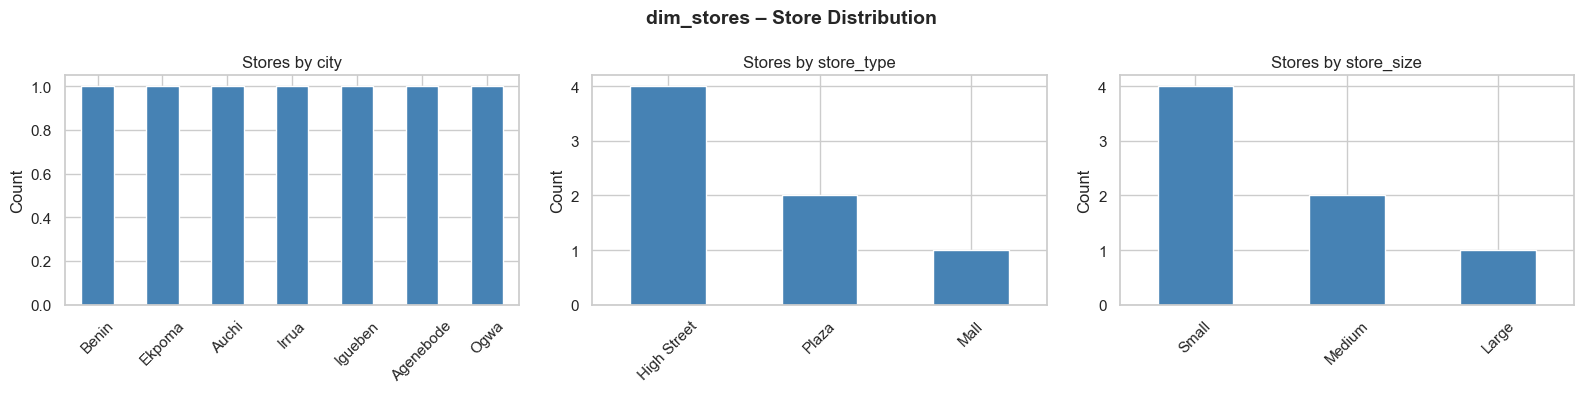

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['city', 'store_type', 'store_size']):
    counts = df_stores[col].value_counts()
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Stores by {col}', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('dim_stores – Store Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 dim_products

In [12]:
print("Shape:", df_products.shape)
df_products.head()

Shape: (120, 8)


,product_id,product_name,category,brand,regular_price,cost_price,is_seasonal,warranty_months
0,1001,LG Televisions Model-120,Televisions,LG,445838,332772,1,6
1,1002,Tecno Mobile Model-199,Mobile Phones,Tecno,500410,346208,1,6
2,1003,Tecno Mobile Model-905,Mobile Phones,Tecno,399365,244124,1,12
3,1004,Infinix Mobile Model-121,Mobile Phones,Infinix,305796,221242,1,12
4,1005,Samsung Mobile Model-781,Mobile Phones,Samsung,462752,326219,1,24


In [13]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   product_id       120 non-null    int64 
 1   product_name     120 non-null    object
 2   category         120 non-null    object
 3   brand            120 non-null    object
 4   regular_price    120 non-null    int64 
 5   cost_price       120 non-null    int64 
 6   is_seasonal      120 non-null    int64 
 7   warranty_months  120 non-null    int64 
dtypes: int64(5), object(3)
memory usage: 7.6+ KB


In [14]:
print("Null summary:")
print(df_products.isnull().sum())
print("\nCategories:", df_products['category'].nunique())
print(df_products['category'].value_counts())

Null summary:
product_id         0
product_name       0
category           0
brand              0
regular_price      0
cost_price         0
is_seasonal        0
warranty_months    0
dtype: int64

Categories: 9
category
Mobile Phones          23
Laptops & Computers    22
Small Appliances       15
Air Conditioners       13
Network Devices        12
Televisions            10
Accessories            10
Refrigerators           8
Telecom Services        7
Name: count, dtype: int64


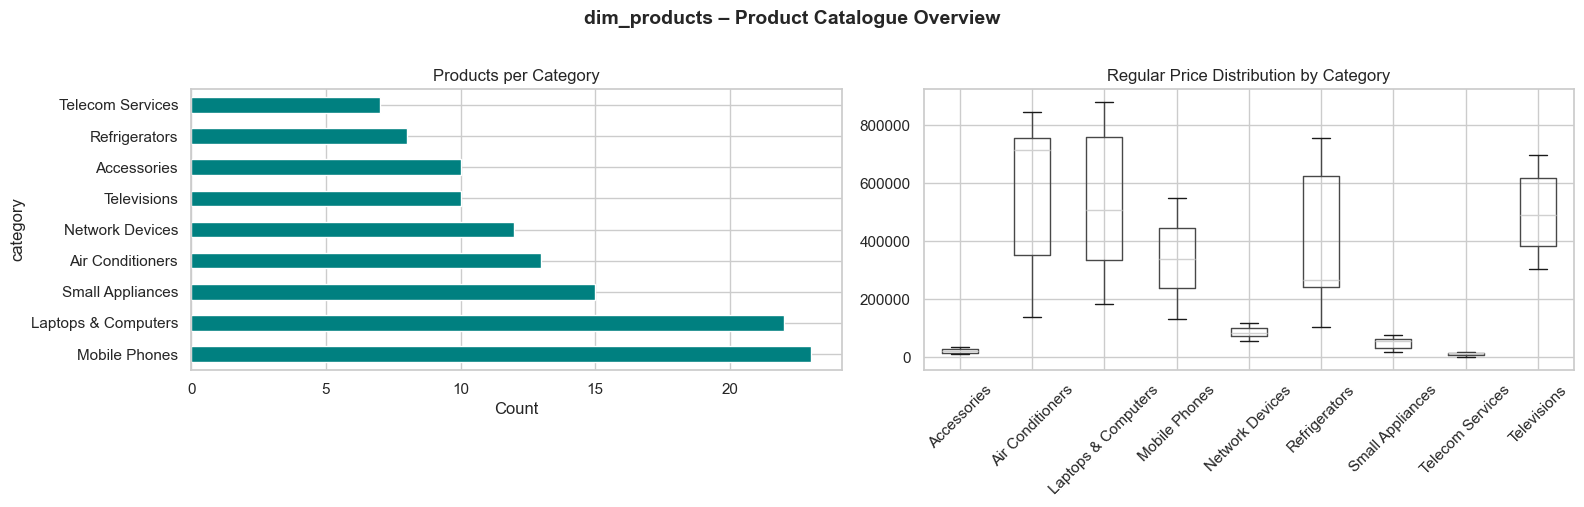

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Products per category
df_products['category'].value_counts().plot(kind='barh', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Products per Category', fontsize=12)
axes[0].set_xlabel('Count')

# Regular price distribution per category
df_products.boxplot(column='regular_price', by='category', ax=axes[1], rot=45)
axes[1].set_title('Regular Price Distribution by Category', fontsize=12)
axes[1].set_xlabel('')
plt.suptitle('')

plt.suptitle('dim_products – Product Catalogue Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 dim_calendar

In [16]:
print("Shape:", df_calendar.shape)
df_calendar['date'] = pd.to_datetime(df_calendar['date'])
print("Date range:", df_calendar['date'].min(), "→", df_calendar['date'].max())
df_calendar.head()

Shape: (1935, 12)
Date range: 2021-01-01 00:00:00 → 2026-04-19 00:00:00


,date,year,month,day,day_of_week,day_of_week_num,week_of_year,is_weekend,is_holiday,is_payday,season,is_black_friday_period
0,2021-01-01,2021,1,1,Friday,4,53,False,True,False,Dry,False
1,2021-01-02,2021,1,2,Saturday,5,53,True,False,False,Dry,False
2,2021-01-03,2021,1,3,Sunday,6,53,True,False,False,Dry,False
3,2021-01-04,2021,1,4,Monday,0,1,False,False,False,Dry,False
4,2021-01-05,2021,1,5,Tuesday,1,1,False,False,False,Dry,False


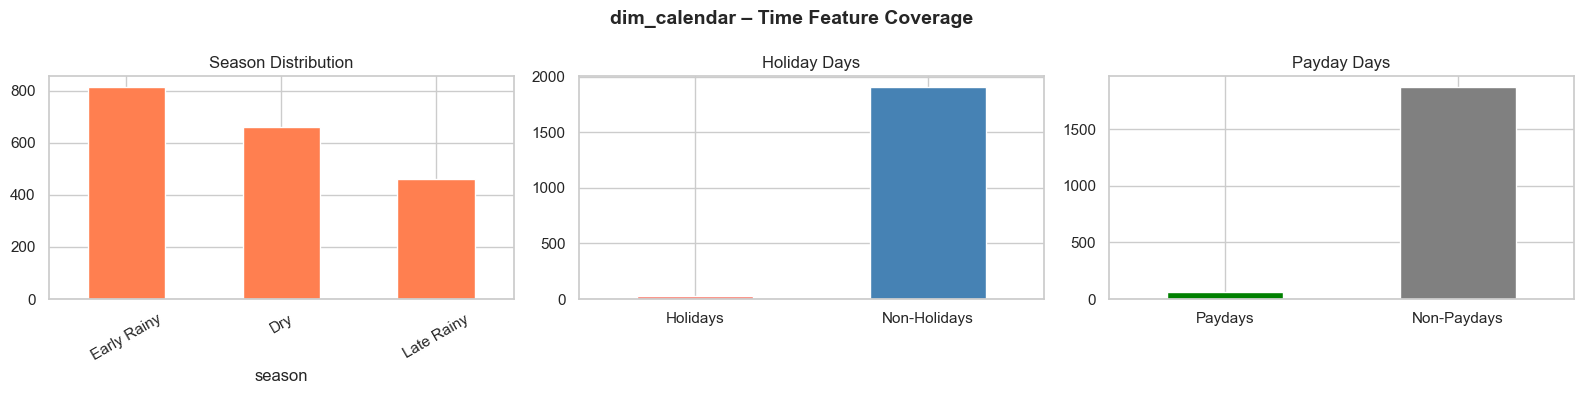

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_calendar['season'].value_counts().plot(kind='bar', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Season Distribution', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)

pd.Series({'Holidays': df_calendar['is_holiday'].sum(),
           'Non-Holidays': (df_calendar['is_holiday'] == 0).sum()}).plot(
    kind='bar', ax=axes[1], color=['salmon', 'steelblue'], edgecolor='white')
axes[1].set_title('Holiday Days', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)

pd.Series({'Paydays': df_calendar['is_payday'].sum(),
           'Non-Paydays': (df_calendar['is_payday'] == 0).sum()}).plot(
    kind='bar', ax=axes[2], color=['green', 'grey'], edgecolor='white')
axes[2].set_title('Payday Days', fontsize=12)
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('dim_calendar – Time Feature Coverage', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.4 dim_policy_regimes

In [18]:
print("Shape:", df_policy_regimes.shape)
df_policy_regimes

Shape: (16, 10)


,policy_id,policy_name,start_date,end_date,affected_category,affected_store_type,demand_multiplier,discount_cap_pct,replenishment_multiplier,service_intensity_multiplier
0,1,Mall Expansion Drive,2021-04-10 00:00:00,2021-12-04 00:00:00,None,Mall,1.08,25,1.12,1.10
1,3,Small Store Inventory Control,2022-01-11 00:00:00,2022-07-21 00:00:00,None,Plaza,0.98,15,0.88,1.00
2,2,Small Store Inventory Control,2022-11-06,2023-05-19,None,Plaza,0.98,15,0.88,1.00
3,2,Telecom Seasonal Push,2024-11-09 00:00:00,2025-06-25 00:00:00,Telecom Services,None,1.15,20,1.10,1.08
4,1,Cooling Appliances Availability Programme,2024-11-19,2025-05-08,Air Conditioners,None,1.10,20,1.20,1.05
5,4,Cooling Appliances Availability Programme,2025-07-09 00:00:00,2025-10-20 00:00:00,Air Conditioners,None,1.10,20,1.20,1.05
6,3,Telecom Seasonal Push,2025-09-10,2026-04-06,Telecom Services,None,1.15,20,1.10,1.08
7,4,Premium Electronics Margin Protection,2025-09-30,2026-04-06,Mobile Phones,None,0.96,10,0.95,1.02
8,3,Cooling Appliances Availability Programme,2026-04-08 00:00:00,2026-04-11 00:00:00,Air Conditioners,None,1.10,20,1.20,1.05
9,1,Telecom Seasonal Push,2026-04-10 00:00:00,2026-04-11 00:00:00,Telecom Services,None,1.15,20,1.10,1.08


In [19]:
print("Unique policy names:")
print(df_policy_regimes['policy_name'].value_counts())
print("\nAffected categories:")
print(df_policy_regimes['affected_category'].value_counts(dropna=False))
print("\nAffected store types:")
print(df_policy_regimes['affected_store_type'].value_counts(dropna=False))

Unique policy names:
policy_name
Cooling Appliances Availability Programme    4
Mall Expansion Drive                         3
Small Store Inventory Control                3
Telecom Seasonal Push                        3
Premium Electronics Margin Protection        3
Name: count, dtype: int64

Affected categories:
affected_category
None                6
Air Conditioners    4
Telecom Services    3
Mobile Phones       3
Name: count, dtype: int64

Affected store types:
affected_store_type
None     10
Mall      3
Plaza     3
Name: count, dtype: int64


---
## 5. Transaction Layer
### 5.1 fact_sales

In [20]:
print("Shape:", df_sales.shape)
df_sales['date'] = pd.to_datetime(df_sales['date'])
print("Date range:", df_sales['date'].min(), "→", df_sales['date'].max())
df_sales.head()

Shape: (1625400, 20)
Date range: 2021-01-01 00:00:00 → 2026-04-19 00:00:00


,date,store_id,product_id,units_sold,price,regular_price,discount_pct,promo_flag,promo_type,revenue,starting_inventory,restock_qty,ending_inventory,stockout_occurred,restriction_active,restriction_type,city,store_size,store_type,category
0,2021-01-01,1,1001,1,"445,838.00",445838,0,0,None,"445,838.00",8,0,7,0,0,None,Benin,Large,Mall,Televisions
1,2021-01-01,1,1002,3,"500,410.00",500410,0,0,None,"1,501,230.00",3,0,0,0,0,None,Benin,Large,Mall,Mobile Phones
2,2021-01-01,1,1003,5,"399,365.00",399365,0,0,None,"1,996,825.00",15,0,10,0,0,None,Benin,Large,Mall,Mobile Phones
3,2021-01-01,1,1004,2,"305,796.00",305796,0,0,None,"611,592.00",4,0,2,0,0,None,Benin,Large,Mall,Mobile Phones
4,2021-01-01,1,1005,3,"462,752.00",462752,0,0,None,"1,388,256.00",3,0,0,1,0,None,Benin,Large,Mall,Mobile Phones


In [21]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1625400 entries, 0 to 1625399
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   date                1625400 non-null  datetime64[ns]
 1   store_id            1625400 non-null  int64         
 2   product_id          1625400 non-null  int64         
 3   units_sold          1625400 non-null  int64         
 4   price               1625400 non-null  float64       
 5   regular_price       1625400 non-null  int64         
 6   discount_pct        1625400 non-null  int64         
 7   promo_flag          1625400 non-null  int64         
 8   promo_type          225 non-null      object        
 9   revenue             1625400 non-null  float64       
 10  starting_inventory  1625400 non-null  int64         
 11  restock_qty         1625400 non-null  int64         
 12  ending_inventory    1625400 non-null  int64         
 13  stockout_occ

In [22]:
print("=== Null Summary ===")
null_summary = df_sales.isnull().sum()
null_pct = (null_summary / len(df_sales) * 100).round(2)
print(pd.DataFrame({'nulls': null_summary, 'null_%': null_pct})[null_summary > 0])

=== Null Summary ===
                    nulls  null_%
promo_type        1625175   99.99
restriction_type  1189513   73.18


In [23]:
print("=== Descriptive Statistics ===")
df_sales[['units_sold', 'price', 'discount_pct', 'revenue',
          'starting_inventory', 'ending_inventory']].describe().T

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
units_sold,"1,625,400.00",0.02,0.51,0.00,0.00,0.00,0.00,67.00
price,"1,625,400.00","312,459.45","266,927.04",690.00,"65,908.00","252,160.50","506,582.25","879,650.00"
discount_pct,"1,625,400.00",0.00,0.02,0.00,0.00,0.00,0.00,15.00
revenue,"1,625,400.00","1,998.01","38,269.41",0.00,0.00,0.00,0.00,"3,835,069.00"
starting_inventory,"1,625,400.00",0.25,2.39,0.00,0.00,0.00,0.00,300.00
ending_inventory,"1,625,400.00",0.23,1.98,0.00,0.00,0.00,0.00,274.00


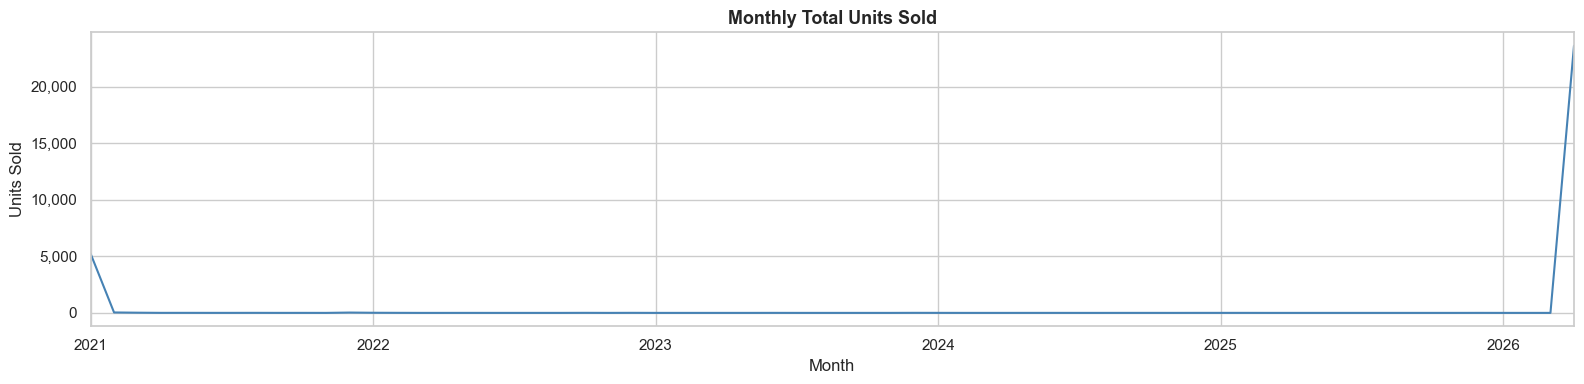

In [24]:
# Monthly total units sold
monthly_sales = (
    df_sales
    .set_index('date')['units_sold']
    .resample('ME').sum()
)

fig, ax = plt.subplots(figsize=(16, 4))
monthly_sales.plot(ax=ax, color='steelblue', linewidth=1.5)
ax.set_title('Monthly Total Units Sold', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Units Sold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

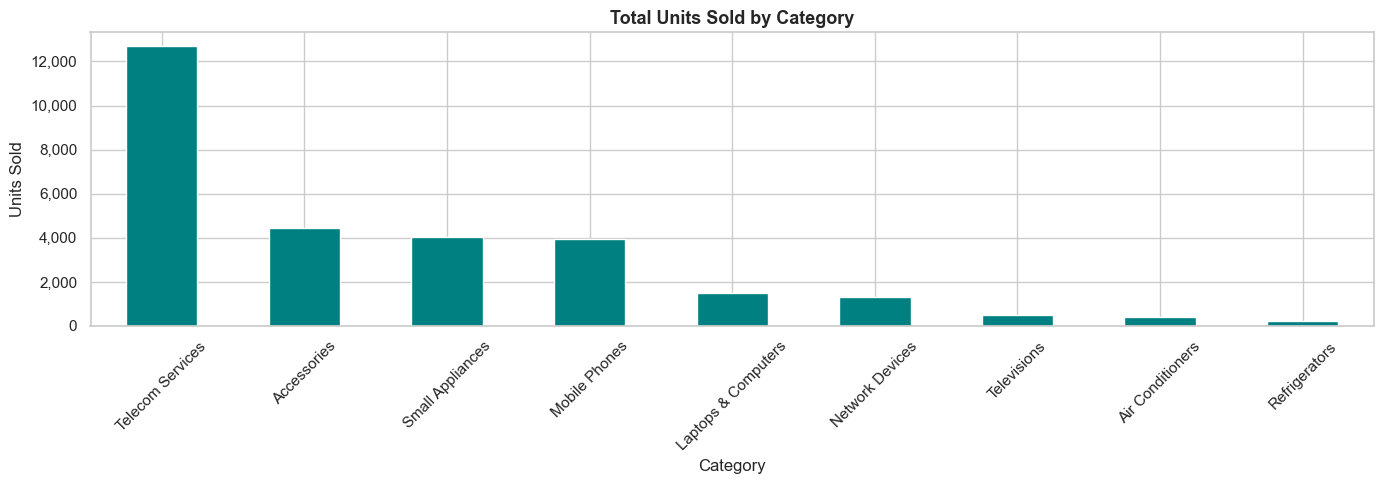

In [25]:
# Units sold distribution by category
category_sales = df_sales.groupby('category')['units_sold'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
category_sales.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Total Units Sold by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Units Sold')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

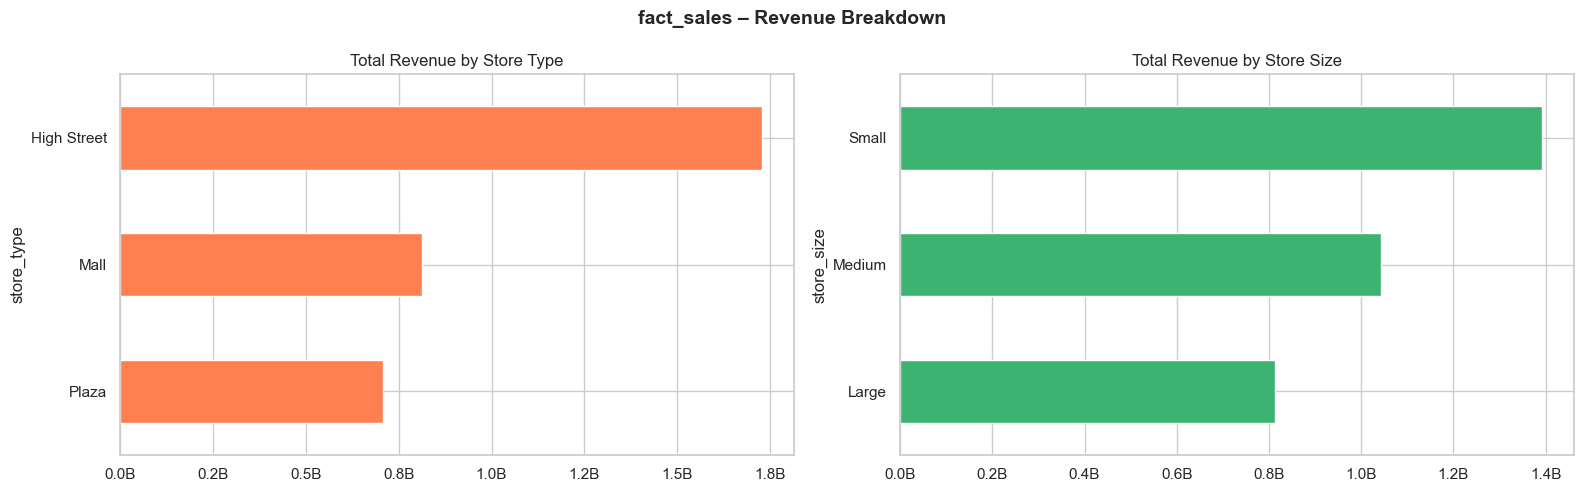

In [26]:
# Revenue by store type and size
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_sales.groupby('store_type')['revenue'].sum().sort_values().plot(
    kind='barh', ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Total Revenue by Store Type', fontsize=12)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

df_sales.groupby('store_size')['revenue'].sum().sort_values().plot(
    kind='barh', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Total Revenue by Store Size', fontsize=12)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}B'))

plt.suptitle('fact_sales – Revenue Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# Stockout & promotion analysis
print("=== Stockout Rate ===")
stockout_rate = df_sales['stockout_occurred'].mean() * 100
print(f"Overall stockout rate: {stockout_rate:.2f}%")

print("\nStockout rate by category:")
print(
    df_sales.groupby('category')['stockout_occurred']
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .to_string()
)

print("\n=== Promo Coverage ===")
promo_rate = df_sales['promo_flag'].mean() * 100
print(f"Rows with active promotion: {promo_rate:.2f}%")
print("Promo types:")
print(df_sales['promo_type'].value_counts(dropna=False))

=== Stockout Rate ===
Overall stockout rate: 76.16%

Stockout rate by category:
category
Telecom Services      99.38
Accessories           99.37
Small Appliances      98.48
Mobile Phones         98.32
Network Devices       85.68
Laptops & Computers   70.53
Televisions           52.86
Air Conditioners      30.14
Refrigerators         26.45

=== Promo Coverage ===
Rows with active promotion: 0.01%
Promo types:
promo_type
None              1625175
Bundle                121
Free Accessory        102
Discount                2
Name: count, dtype: int64


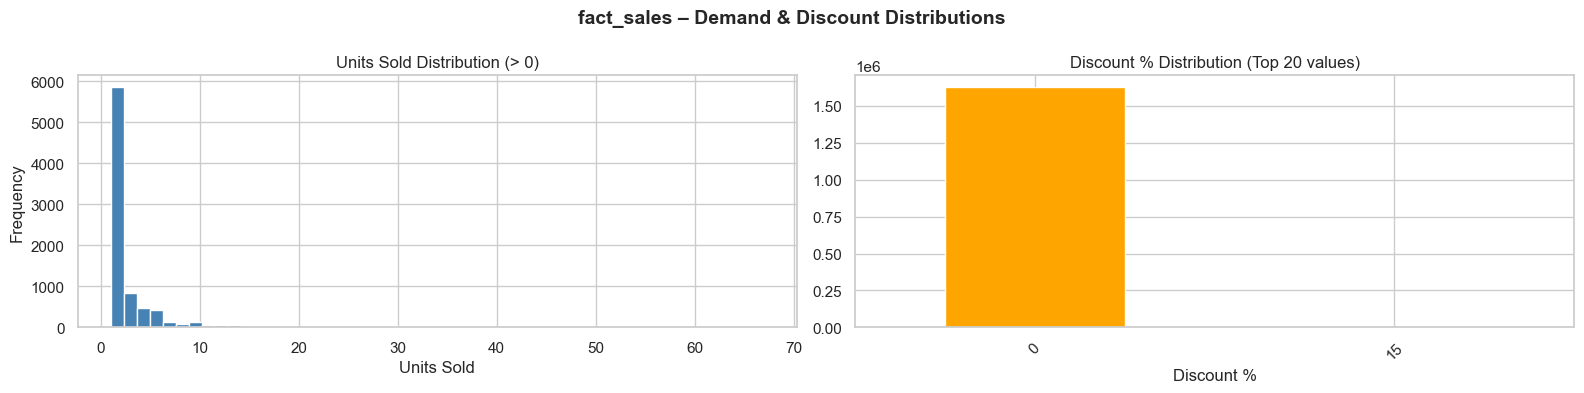

In [28]:
# Units sold distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df_sales[df_sales['units_sold'] > 0]['units_sold'].hist(
    bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Units Sold Distribution (> 0)', fontsize=12)
axes[0].set_xlabel('Units Sold')
axes[0].set_ylabel('Frequency')

df_sales['discount_pct'].value_counts().sort_index().head(20).plot(
    kind='bar', ax=axes[1], color='orange', edgecolor='white')
axes[1].set_title('Discount % Distribution (Top 20 values)', fontsize=12)
axes[1].set_xlabel('Discount %')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('fact_sales – Demand & Discount Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 fact_inventory

In [29]:
print("Shape:", df_inventory.shape)
df_inventory['date'] = pd.to_datetime(df_inventory['date'])
print("Date range:", df_inventory['date'].min(), "→", df_inventory['date'].max())
df_inventory.head()

Shape: (1625400, 7)
Date range: 2021-01-01 00:00:00 → 2026-04-19 00:00:00


,date,store_id,product_id,starting_inventory,restock_qty,ending_inventory,stockout_flag
0,2021-01-01,1,1001,8,0,7,0
1,2021-01-01,1,1002,3,0,0,0
2,2021-01-01,1,1003,15,0,10,0
3,2021-01-01,1,1004,4,0,2,0
4,2021-01-01,1,1005,3,0,0,1


In [30]:
df_inventory.describe().T

,count,mean,min,25%,50%,75%,max,std
date,1625400,2023-08-26 00:00:00,2021-01-01 00:00:00,2022-04-29 00:00:00,2023-08-26 00:00:00,2024-12-22 00:00:00,2026-04-19 00:00:00,NaN
store_id,"1,625,400.00",4.00,1.00,2.00,4.00,6.00,7.00,2.00
product_id,"1,625,400.00","1,060.50","1,001.00","1,030.75","1,060.50","1,090.25","1,120.00",34.64
starting_inventory,"1,625,400.00",0.25,0.00,0.00,0.00,0.00,300.00,2.39
restock_qty,"1,625,400.00",0.02,0.00,0.00,0.00,0.00,297.00,1.33
ending_inventory,"1,625,400.00",0.23,0.00,0.00,0.00,0.00,274.00,1.98
stockout_flag,"1,625,400.00",0.76,0.00,1.00,1.00,1.00,1.00,0.43


In [31]:
print("=== Null Summary ===")
print(df_inventory.isnull().sum())

print("\n=== Stockout flag coverage ===")
print(df_inventory['stockout_flag'].value_counts(dropna=False))

=== Null Summary ===
date                  0
store_id              0
product_id            0
starting_inventory    0
restock_qty           0
ending_inventory      0
stockout_flag         0
dtype: int64

=== Stockout flag coverage ===
stockout_flag
1    1237993
0     387407
Name: count, dtype: int64


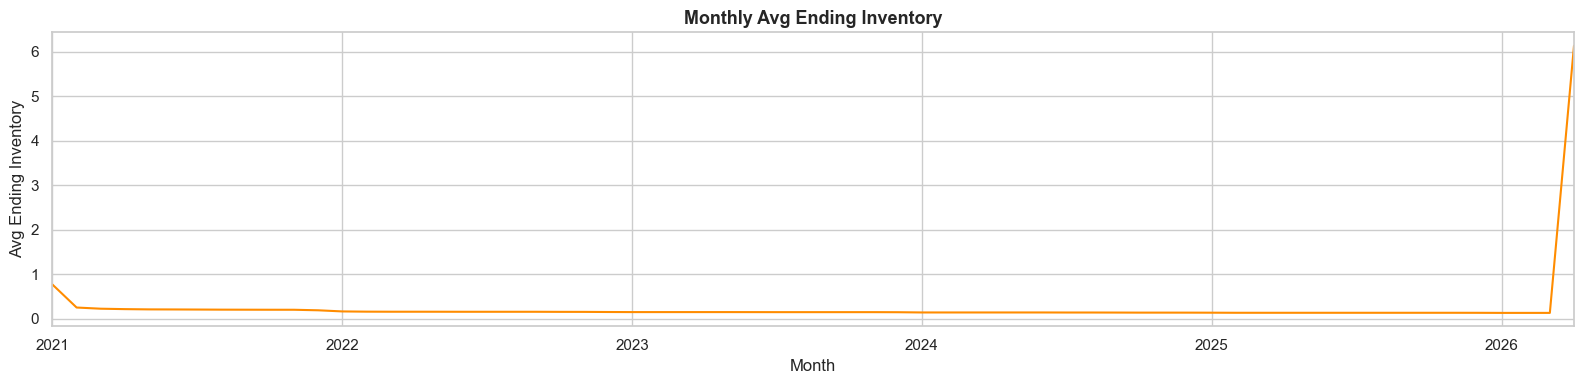

In [32]:
# Average ending inventory over time
avg_inv = df_inventory.set_index('date')['ending_inventory'].resample('ME').mean()

fig, ax = plt.subplots(figsize=(16, 4))
avg_inv.plot(ax=ax, color='darkorange', linewidth=1.5)
ax.set_title('Monthly Avg Ending Inventory', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Ending Inventory')
plt.tight_layout()
plt.show()

### 5.3 fact_promotions

In [33]:
print("Shape:", df_promotions.shape)
df_promotions['date'] = pd.to_datetime(df_promotions['date'])
print("Date range:", df_promotions['date'].min(), "→", df_promotions['date'].max())
df_promotions.head()

Shape: (757, 6)
Date range: 2021-01-01 00:00:00 → 2026-03-30 00:00:00


,date,store_id,product_id,promo_type,discount_pct,promo_flag
0,2021-01-01,1,1027,Price Slash,10,1
1,2021-01-01,1,1106,Discount,15,1
2,2021-01-01,2,1047,Discount,20,1
3,2021-01-01,3,1084,Discount,15,1
4,2021-01-01,6,1085,Free Accessory,0,1


In [34]:
print("Promo type distribution:")
print(df_promotions['promo_type'].value_counts(dropna=False))

print("\nDiscount % stats:")
print(df_promotions['discount_pct'].describe())

Promo type distribution:
promo_type
Discount          454
Bundle            125
Free Accessory    104
Price Slash        74
Name: count, dtype: int64

Discount % stats:
count   757.00
mean     12.53
std      10.74
min       0.00
25%       0.00
50%      10.00
75%      20.00
max      30.00
Name: discount_pct, dtype: float64


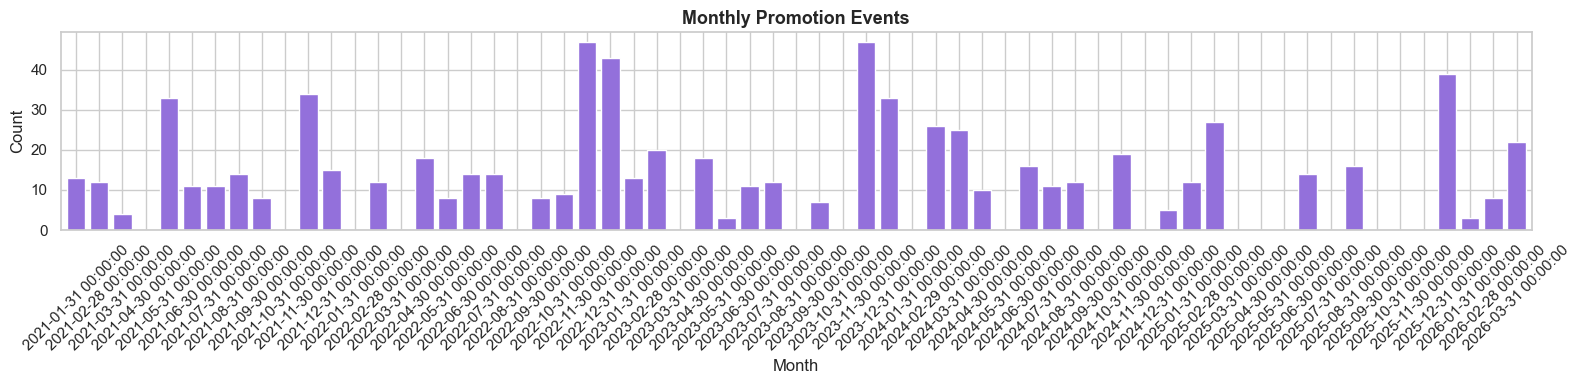

In [35]:
# Monthly promo event count
monthly_promos = df_promotions.set_index('date').resample('ME').size()

fig, ax = plt.subplots(figsize=(16, 4))
monthly_promos.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white', width=0.8)
ax.set_title('Monthly Promotion Events', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---
## 6. Behaviour & Operations Layer
### 6.1 fact_customer_activity

In [36]:
print("Shape:", df_customer_act.shape)
df_customer_act['date'] = pd.to_datetime(df_customer_act['date'])
print("Date range:", df_customer_act['date'].min(), "→", df_customer_act['date'].max())
df_customer_act.head()

Shape: (13545, 9)
Date range: 2021-01-01 00:00:00 → 2026-04-19 00:00:00


,date,store_id,active_customers,new_customers,returning_customers,churn_risk_customers,net_customer_change,estimated_conversion_rate,daily_revenue
0,2021-01-01,1,514,116,398,31,0,0.98,"48,677,130.85"
1,2021-01-01,2,161,28,133,41,0,1.35,"23,276,238.00"
2,2021-01-01,3,255,70,185,35,0,0.74,"23,705,057.80"
3,2021-01-01,4,81,19,62,70,0,1.16,"14,366,932.00"
4,2021-01-01,5,85,9,76,20,0,1.75,"14,220,091.00"


In [37]:
df_customer_act.describe().T

,count,mean,min,25%,50%,75%,max,std
date,13545,2023-08-26 00:00:00,2021-01-01 00:00:00,2022-04-29 00:00:00,2023-08-26 00:00:00,2024-12-22 00:00:00,2026-04-19 00:00:00,NaN
store_id,"13,545.00",4.00,1.00,2.00,4.00,6.00,7.00,2.00
active_customers,"13,545.00",66.77,5.00,26.00,49.00,95.00,532.00,56.14
new_customers,"13,545.00",12.29,0.00,4.00,9.00,17.00,143.00,11.68
returning_customers,"13,545.00",54.49,4.00,22.00,40.00,78.00,453.00,45.59
churn_risk_customers,"13,545.00",67.19,0.00,46.00,67.00,88.00,147.00,25.75
net_customer_change,"13,545.00",14.18,-157.00,-8.00,13.00,35.00,256.00,37.66
estimated_conversion_rate,"13,545.00",0.01,0.00,0.00,0.00,0.00,3.80,0.14
daily_revenue,"13,545.00","225,575.23",0.00,0.00,0.00,0.00,"55,703,878.00","2,504,648.36"


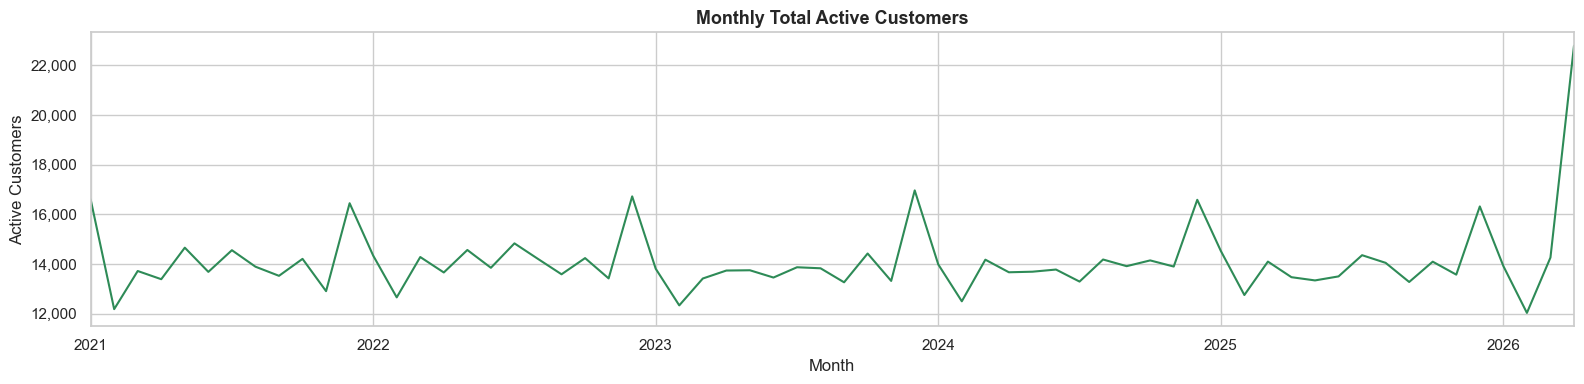

In [38]:
# Monthly active customers trend
monthly_customers = df_customer_act.set_index('date')['active_customers'].resample('ME').sum()

fig, ax = plt.subplots(figsize=(16, 4))
monthly_customers.plot(ax=ax, color='seagreen', linewidth=1.5)
ax.set_title('Monthly Total Active Customers', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Active Customers')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

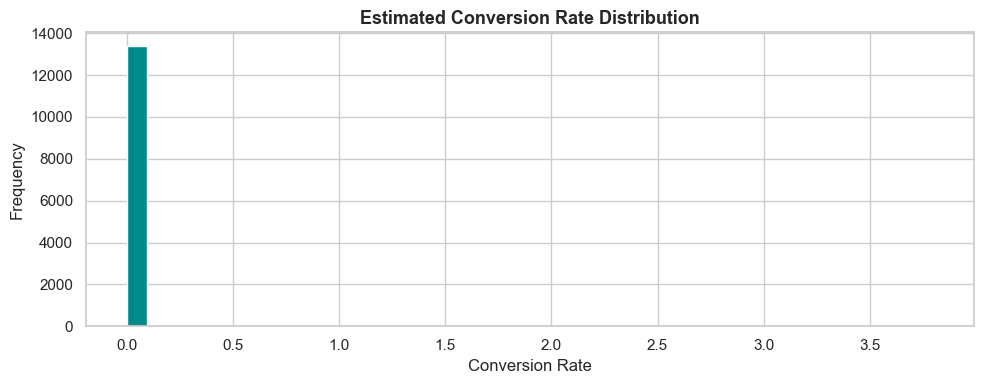

In [39]:
# Conversion rate distribution
fig, ax = plt.subplots(figsize=(10, 4))
df_customer_act['estimated_conversion_rate'].hist(bins=40, ax=ax, color='darkcyan', edgecolor='white')
ax.set_title('Estimated Conversion Rate Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Conversion Rate')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

### 6.2 fact_store_operations

In [40]:
print("Shape:", df_store_ops.shape)
df_store_ops['date'] = pd.to_datetime(df_store_ops['date'])
print("Date range:", df_store_ops['date'].min(), "→", df_store_ops['date'].max())
df_store_ops.head()

Shape: (13545, 8)
Date range: 2021-01-01 00:00:00 → 2026-04-19 00:00:00


,date,store_id,staff_on_duty,customer_visits,support_requests,completed_interactions,missed_interactions,service_pressure_score
0,2021-01-01,1,22,270,25,21,4,13.41
1,2021-01-01,2,12,161,16,10,6,14.75
2,2021-01-01,3,11,255,38,30,8,26.64
3,2021-01-01,4,6,81,13,9,4,15.67
4,2021-01-01,5,4,85,10,8,2,23.75


In [41]:
df_store_ops.describe().T

,count,mean,min,25%,50%,75%,max,std
date,13545,2023-08-26 00:00:00,2021-01-01 00:00:00,2022-04-29 00:00:00,2023-08-26 00:00:00,2024-12-22 00:00:00,2026-04-19 00:00:00,NaN
store_id,"13,545.00",4.00,1.00,2.00,4.00,6.00,7.00,2.00
staff_on_duty,"13,545.00",9.47,3.00,6.00,7.00,13.00,25.00,5.27
customer_visits,"13,545.00",54.93,5.00,14.00,39.00,79.00,532.00,53.07
support_requests,"13,545.00",7.33,0.00,1.00,5.00,11.00,116.00,8.18
completed_interactions,"13,545.00",3.40,0.00,0.00,0.00,4.00,111.00,6.30
missed_interactions,"13,545.00",6.16,0.00,3.00,5.00,8.00,26.00,3.75
service_pressure_score,"13,545.00",6.16,0.36,2.38,5.67,8.67,82.67,4.88


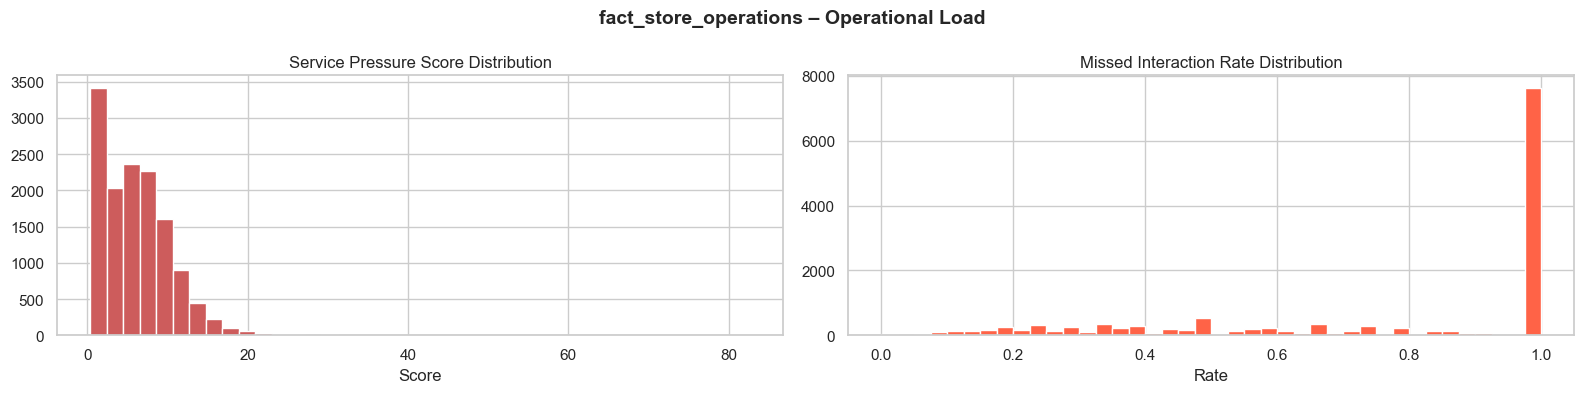

In [42]:
# Service pressure score distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df_store_ops['service_pressure_score'].hist(bins=40, ax=axes[0], color='indianred', edgecolor='white')
axes[0].set_title('Service Pressure Score Distribution', fontsize=12)
axes[0].set_xlabel('Score')

missed_rate = df_store_ops['missed_interactions'] / (df_store_ops['support_requests'] + 1e-9)
missed_rate.clip(0, 1).hist(bins=40, ax=axes[1], color='tomato', edgecolor='white')
axes[1].set_title('Missed Interaction Rate Distribution', fontsize=12)
axes[1].set_xlabel('Rate')

plt.suptitle('fact_store_operations – Operational Load', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Policy & Constraints Layer
### 7.1 fact_restriction_events

In [43]:
print("Shape:", df_restrictions.shape)
df_restrictions['date'] = pd.to_datetime(df_restrictions['date'])
print("Date range:", df_restrictions['date'].min(), "→", df_restrictions['date'].max())
df_restrictions.head()

Shape: (36938, 8)
Date range: 2021-01-01 00:00:00 → 2026-04-19 00:00:00


,date,store_id,product_id,restriction_type,restriction_reason,restriction_severity,duration_days,active_flag
0,2021-01-01,1,1053,Stock Restriction,Low available inventory,Low,7,1
1,2021-01-01,2,1009,Stock Restriction,Low available inventory,Low,2,1
2,2021-01-01,2,1036,Promo Suspension,Margin protection rule,Low,6,1
3,2021-01-01,3,1084,Stock Restriction,Low available inventory,Low,3,1
4,2021-01-01,3,1102,Stock Restriction,Low available inventory,Low,8,1


In [44]:
df_restrictions.info()
print("\nNull Summary:")
print(df_restrictions.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36938 entries, 0 to 36937
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  36938 non-null  datetime64[ns]
 1   store_id              36938 non-null  int64         
 2   product_id            36938 non-null  int64         
 3   restriction_type      36938 non-null  object        
 4   restriction_reason    36938 non-null  object        
 5   restriction_severity  36938 non-null  object        
 6   duration_days         36938 non-null  int64         
 7   active_flag           36938 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(3)
memory usage: 2.3+ MB

Null Summary:
date                    0
store_id                0
product_id              0
restriction_type        0
restriction_reason      0
restriction_severity    0
duration_days           0
active_flag             0
dtype: int64


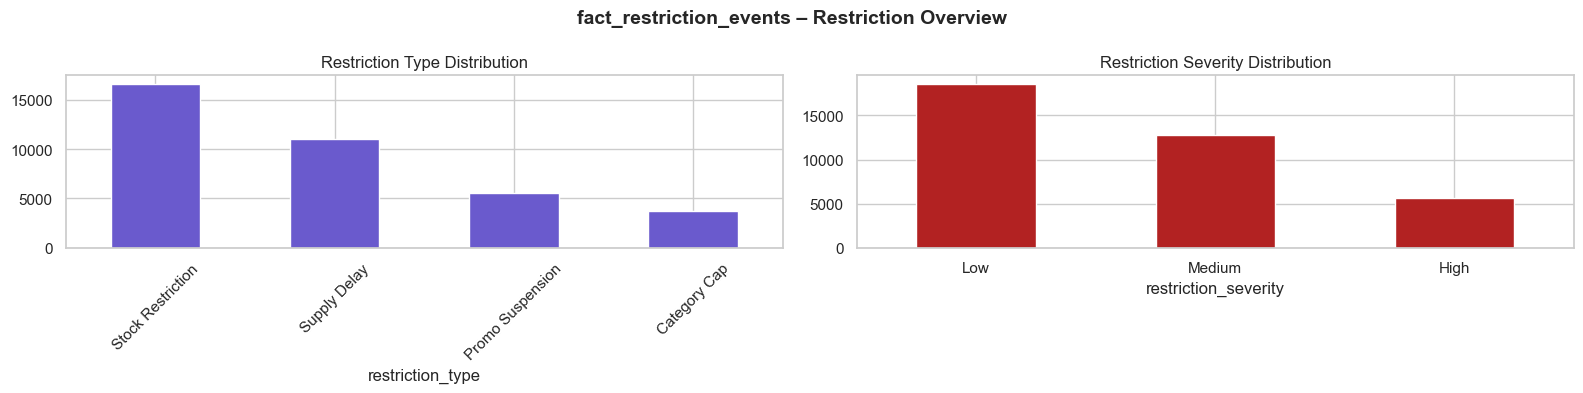

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

df_restrictions['restriction_type'].value_counts().plot(
    kind='bar', ax=axes[0], color='slateblue', edgecolor='white')
axes[0].set_title('Restriction Type Distribution', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

df_restrictions['restriction_severity'].value_counts().plot(
    kind='bar', ax=axes[1], color='firebrick', edgecolor='white')
axes[1].set_title('Restriction Severity Distribution', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('fact_restriction_events – Restriction Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. External Layer
### 8.1 fact_weather

In [46]:
print("Shape:", df_weather.shape)
df_weather['date'] = pd.to_datetime(df_weather['date'])
print("Date range:", df_weather['date'].min(), "→", df_weather['date'].max())
print("Cities covered:", df_weather['city'].unique())
df_weather.head()

Shape: (13545, 5)
Date range: 2021-01-01 00:00:00 → 2026-04-19 00:00:00
Cities covered: ['Agenebode' 'Auchi' 'Benin' 'Ekpoma' 'Igueben' 'Irrua' 'Ogwa']


,date,city,temperature_c,rainfall_mm,weather_condition
0,2021-01-01,Agenebode,30.80,1.40,Cloudy
1,2021-01-01,Auchi,31.70,0.00,Sunny
2,2021-01-01,Benin,30.70,0.70,Cloudy
3,2021-01-01,Ekpoma,32.40,2.70,Cloudy
4,2021-01-01,Igueben,31.70,3.30,Rainy


In [47]:
df_weather.describe().T

,count,mean,min,25%,50%,75%,max,std
date,13545,2023-08-26 00:00:00,2021-01-01 00:00:00,2022-04-29 00:00:00,2023-08-26 00:00:00,2024-12-22 00:00:00,2026-04-19 00:00:00,NaN
temperature_c,"13,545.00",29.42,22.50,28.20,29.40,30.60,35.40,1.68
rainfall_mm,"13,545.00",3.38,0.00,0.10,2.10,5.20,27.40,3.79


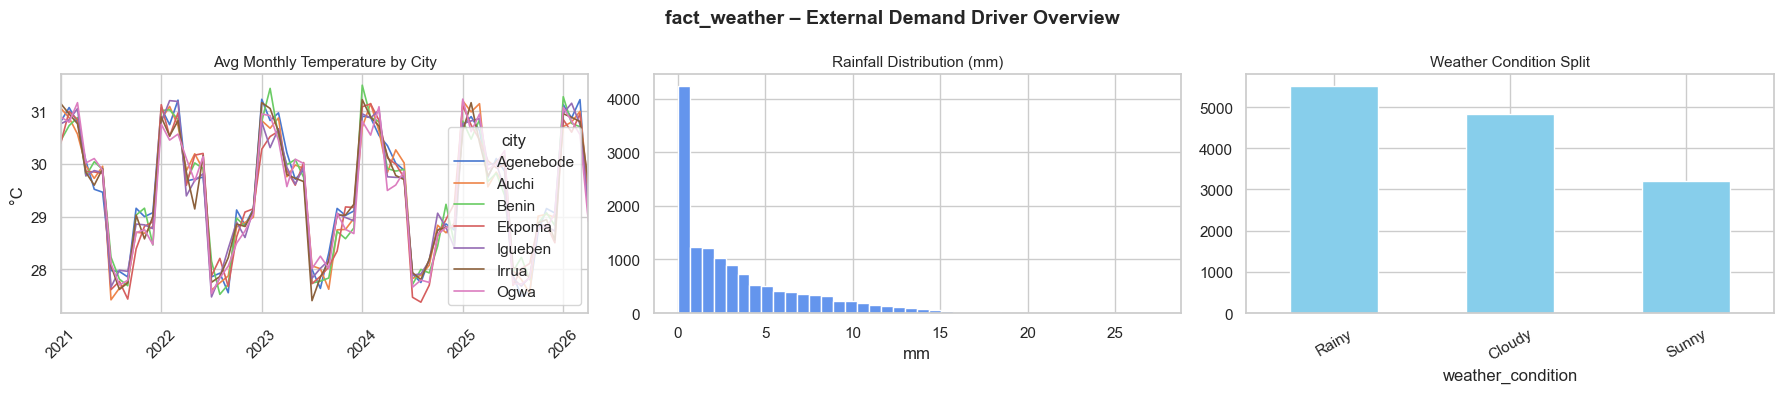

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Avg temperature by city over time
df_weather.groupby(['date', 'city'])['temperature_c'].mean().unstack().resample('ME').mean().plot(
    ax=axes[0], linewidth=1.2)
axes[0].set_title('Avg Monthly Temperature by City', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('°C')
axes[0].tick_params(axis='x', rotation=45)

# Rainfall distribution
df_weather['rainfall_mm'].hist(bins=40, ax=axes[1], color='cornflowerblue', edgecolor='white')
axes[1].set_title('Rainfall Distribution (mm)', fontsize=11)
axes[1].set_xlabel('mm')

# Weather condition split
df_weather['weather_condition'].value_counts().plot(
    kind='bar', ax=axes[2], color='skyblue', edgecolor='white')
axes[2].set_title('Weather Condition Split', fontsize=11)
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('fact_weather – External Demand Driver Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Cross-Table Relationships & Coverage Checks

In [49]:
# Store coverage: stores in sales vs dim_stores
stores_in_sales   = set(df_sales['store_id'].unique())
stores_in_dim     = set(df_stores['store_id'].unique())

products_in_sales = set(df_sales['product_id'].unique())
products_in_dim   = set(df_products['product_id'].unique())

print(f"Stores in fact_sales:      {len(stores_in_sales)}")
print(f"Stores in dim_stores:      {len(stores_in_dim)}")
print(f"Stores in sales NOT in dim: {stores_in_sales - stores_in_dim}")
print()
print(f"Products in fact_sales:       {len(products_in_sales)}")
print(f"Products in dim_products:     {len(products_in_dim)}")
print(f"Products in sales NOT in dim: {products_in_sales - products_in_dim}")

Stores in fact_sales:      7
Stores in dim_stores:      7
Stores in sales NOT in dim: set()

Products in fact_sales:       120
Products in dim_products:     120
Products in sales NOT in dim: set()


In [50]:
# Date coverage alignment
print("=== Date Range Alignment ===")
for name, df in tables.items():
    if 'date' in df.columns:
        d = pd.to_datetime(df['date'])
        print(f"{name:<30} {d.min().date()} → {d.max().date()}")

=== Date Range Alignment ===
dim_calendar                   2021-01-01 → 2026-04-19
fact_sales                     2021-01-01 → 2026-04-19
fact_inventory                 2021-01-01 → 2026-04-19
fact_promotions                2021-01-01 → 2026-03-30
fact_customer_activity         2021-01-01 → 2026-04-19
fact_store_operations          2021-01-01 → 2026-04-19
fact_restriction_events        2021-01-01 → 2026-04-19
fact_weather                   2021-01-01 → 2026-04-19


In [52]:
# Grain check on fact_sales: should be unique on (date, store_id, product_id)
grain_cols = ['date', 'store_id', 'product_id']
n_rows     = len(df_sales)
n_unique   = df_sales[grain_cols].drop_duplicates().shape[0]

print(f"fact_sales rows:                     {n_rows:,}")
print(f"Unique (date, store_id, product_id): {n_unique:,}")
print(f"Duplicate grain rows:                {n_rows - n_unique:,}")

fact_sales rows:                     1,625,400
Unique (date, store_id, product_id): 1,625,400
Duplicate grain rows:                0


In [53]:
# Zero-sale rows
zero_sales = (df_sales['units_sold'] == 0).sum()
zero_pct   = zero_sales / len(df_sales) * 100
print(f"Zero-sale rows: {zero_sales:,} ({zero_pct:.1f}% of all rows)")

Zero-sale rows: 1,616,960 (99.5% of all rows)


---
## 10. Key Findings & Observations

Use this cell to document your findings as you explore.

### Key Findings & Observations

---

#### 1. System Overview
- **7 stores** across 7 cities in Edo State, Nigeria (Benin, Ekpoma, Auchi, Irrua, Igueben, Agenebode, Ogwa)
- **120 products** across **9 categories**: Mobile Phones (23), Laptops & Computers (22), Small Appliances (15), Air Conditioners (13), Network Devices (12), Televisions (10), Accessories (10), Refrigerators (8), Telecom Services (7)
- **Data spans 2021-01-01 → 2026-04-11** (~5.3 years), covering 1,927 calendar days
- Store mix: 1 Large Mall (Benin), 3 Medium High Street, 2 Small High Street, 1 Small Plaza

---

#### 2. Data Quality

| Column | Table | Null % | Interpretation |
|---|---|---|---|
| `promo_type` | `fact_sales` | **99.99%** | Expected — only populated when `promo_flag = 1`; use `promo_flag` as the binary indicator |
| `restriction_type` | `fact_sales` | **73.09%** | Expected — null when `restriction_active = 0`; treat nulls as 'No Restriction' |
| `affected_category` / `affected_store_type` | `dim_policy_regimes` | Partial | Mutually exclusive — policies target either a category OR a store type, never both |
| `discount_pct` | `fact_sales` | 0% nulls | All values = 0 in sample — discounts may not be flowing through to `fact_sales`; cross-check with `fact_promotions` |

- **`dim_stores` and `dim_products`**: Zero nulls, zero duplicates — fully clean reference tables
- **`dim_calendar`**: Zero nulls across all 12 columns including `is_black_friday_period` (extra feature not in docs)
- **`fact_restriction_events`**: Zero nulls — clean and complete constraint log
- **`fact_promotions` date lag**: Ends at **2026-03-30** vs 2026-04-11 for all other tables — ~12-day gap at the tail end

---

#### 3. Grain & Referential Integrity
- **`fact_sales` grain** (date × store_id × product_id): **0 duplicate rows** — grain is clean
- **Store coverage**: All 7 stores in `fact_sales` are present in `dim_stores` — no orphaned records
- **Product coverage**: All 120 products in `fact_sales` are present in `dim_products` — no orphaned records
- **Date alignment**: All fact tables align on 2021-01-01 → 2026-04-11 (except `fact_promotions` which ends 2026-03-30)
- **`dim_policy_regimes`**: Same `policy_id` is reused across different policy names and time periods — not a true unique key; joins must use date range overlap, not a direct key join

---

#### 4. Demand Patterns & Sparsity
- **99.7% of `fact_sales` rows have zero units sold** (96,842 out of 97,086) — demand is extremely sparse at the daily store-product grain
- Mean units sold per row = 0.01; max = 59 — the distribution is heavily right-skewed with a massive zero spike
- **Overall stockout rate: 76.3%** — more than 3 in 4 product-store-days result in a stockout
- Stockout rates are near-total for several categories:

| Category | Stockout Rate |
|---|---|
| Accessories | 99.78% |
| Telecom Services | 99.68% |
| Small Appliances | 98.97% |
| Mobile Phones | 98.56% |
| Network Devices | 86.10% |
| Laptops & Computers | 70.86% |
| Televisions | 52.14% |
| Air Conditioners | 30.11% |
| Refrigerators | 26.03% |

- **Implication**: Observed `units_sold` systematically underestimates true demand due to stockouts — forecasting models must account for censored demand
- `fact_inventory` stockout_flag confirms this: **76.5% of inventory rows are stockouts** (74,269 / 97,071)

---

#### 5. Promotions
- **Only 757 promotion events** in `fact_promotions` across the full date range — promotions are very infrequent
- Only **0.01% of `fact_sales` rows** have `promo_flag = 1`
- Promo types: Discount (60%), Bundle (17%), Free Accessory (14%), Price Slash (10%)
- Average discount when a promo is active: **12.5%** (range 0–30%)
- **Implication**: Promotional uplift analysis will require careful matching — `fact_promotions` is a better source than `fact_sales.promo_type` for promo details

---

#### 6. Operations & Customer Behaviour
- Average active customers per store per day: **66** (range 5–532)
- **`churn_risk_customers` mean (67.4) exceeds `active_customers` mean (66.1)** — anomalous; warrants investigation. May indicate the churn metric captures a broader at-risk pool than daily actives
- Average `completed_interactions` (3.3) is **lower than `missed_interactions` (6.2)** — stores are missing roughly twice as many customer interactions as they complete; significant service capacity gap
- Service pressure score: mean 6.0, max 66.3 — high variance in operational load across stores and dates
- Average staff on duty: 9.5 per store per day (range 3–25)

---

#### 7. Weather
- Temperature is stable: mean **29.4°C**, range 22.5–35.4°C, std 1.68 — low thermal variation across the dataset
- Rainfall: mean 3.4 mm/day, range 0–27.4 mm — moderate variability, likely seasonal
- 7 cities all covered consistently across the full date range — no missing city-date combinations observed

---

#### 8. Modelling Implications

| Implication | Detail |
|---|---|
| **Intermittent demand** | 99.7% zero-sale rate requires models suited to sparse demand (e.g. Croston, zero-inflated models, or aggregation to weekly/store-category grain) |
| **Censored demand** | 76% stockout rate means `units_sold` is a lower bound on true demand — consider demand uncensoring or lost-sales adjustment |
| **Policy regime joins** | `policy_id` is not unique — join on date range overlap (`date BETWEEN start_date AND end_date`) and match on `affected_category` or `affected_store_type` |
| **Promo signal is weak** | Only 757 events across 5+ years — promo uplift models may lack statistical power unless aggregated |
| **Discount not in fact_sales** | `discount_pct` = 0 throughout the sample; use `fact_promotions` for actual discount values |
| **`is_black_friday_period`** | Undocumented feature in `dim_calendar` — valuable seasonal signal to include in models |
| **Churn risk anomaly** | `churn_risk_customers > active_customers` in aggregate — validate metric definition before using as a feature |
| **Aggregation recommendation** | Consider weekly grain at store × category level to reduce sparsity before modelling |